# 📊 Exploratory Data Analysis (EDA)

## 🎯 Objective
The purpose of this notebook is to perform an exploratory data analysis (EDA) on the **Insurance Charges Dataset** in order to:

- Understand the structure and characteristics of the dataset
- Identify missing values and potential data quality issues
- Analyze the distribution of the target variable (`charges`)
- Explore relationships between input features and the target variable
- Identify important predictors for the downstream ML task

---

## 🧾 Dataset Description

This dataset contains medical cost personal information for insurance customers.  
The main goal is to predict the **insurance charges** based on demographic and health-related attributes.

| Feature | Description |
|--------|-------------|
| age | Age of the primary beneficiary |
| sex | Gender of the insurance contractor |
| bmi | Body Mass Index |
| children | Number of dependents covered |
| smoker | Smoking status |
| region | Residential area in the US |
| charges | Individual medical costs billed by health insurance |

---

## 🔍 EDA Stages

### 1️⃣ Data Understanding
- Dataset shape
- Data types
- Summary statistics
- Target variable identification

### 2️⃣ Data Quality Check
- Missing values
- Duplicate records
- Outliers detection

### 3️⃣ Univariate Analysis
- Distribution of numerical features
- Distribution of categorical features
- Target variable distribution (`charges`)

### 4️⃣ Bivariate Analysis
- Relationship between numerical features and target
- Relationship between categorical features and target
- Group-based charge comparison

### 5️⃣ Correlation Analysis
- Numerical feature correlation matrix
- Multicollinearity assessment

---

## 📌 Expected Insights

From this analysis we expect to:

- Identify the most relevant predictors for insurance charges
- Detect non-linear relationships
- Understand the impact of lifestyle variables such as smoking
- Guide feature engineering and modeling decisions

In [6]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))  # si corres desde notebooks/
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "insurance", "insurance.csv")

print("CWD:", os.getcwd())
print("DATA_PATH:", DATA_PATH)
print("EXISTS:", os.path.exists(DATA_PATH))

df = pd.read_csv(DATA_PATH)
df.head()

CWD: d:\Maestria DS\Ciclo III\C03_MLOps\Project_example\mlops-final-project-Jonathan_Sanchez\notebooks
DATA_PATH: d:\Maestria DS\Ciclo III\C03_MLOps\Project_example\mlops-final-project-Jonathan_Sanchez\data\insurance\insurance.csv
EXISTS: True


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.shape, df.columns

((1338, 7),
 Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object'))

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [10]:
df.isna().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1)

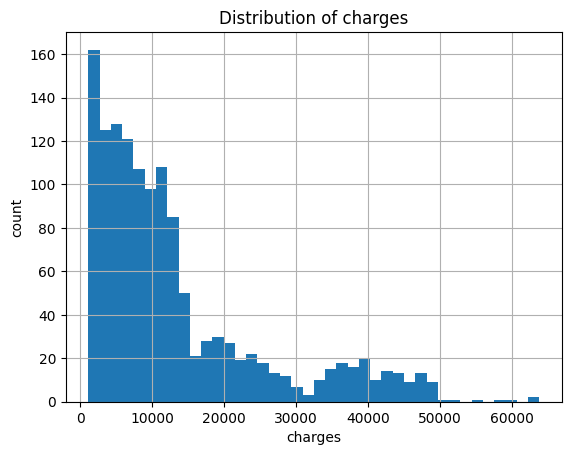

In [12]:
plt.figure()
df["charges"].hist(bins=40)
plt.title("Distribution of charges")
plt.xlabel("charges")
plt.ylabel("count")
plt.show()

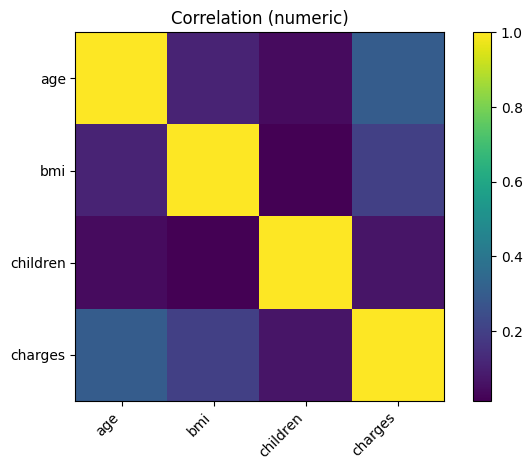

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.title("Correlation (numeric)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()

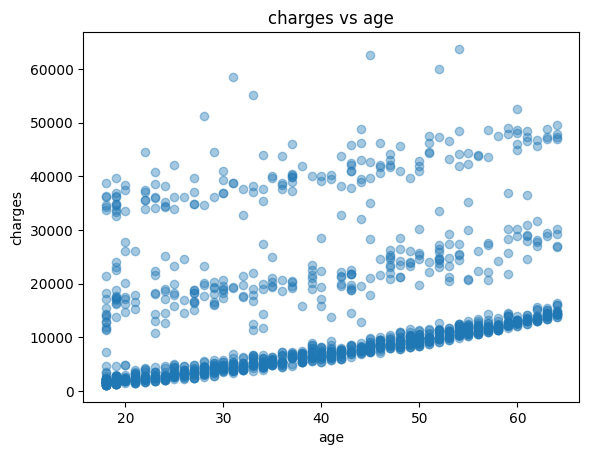

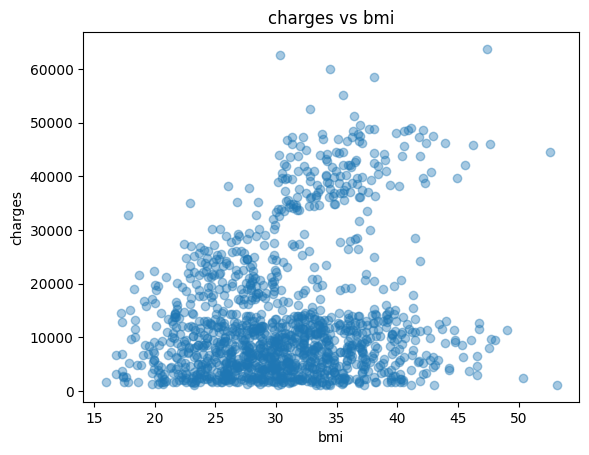

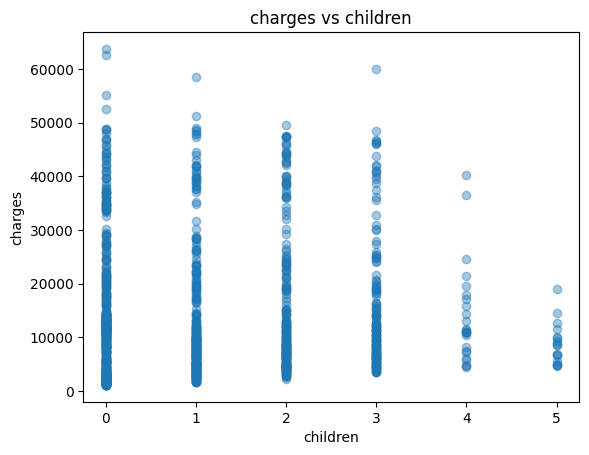

In [14]:
for col in ["age", "bmi", "children"]:
    plt.figure()
    plt.scatter(df[col], df["charges"], alpha=0.4)
    plt.title(f"charges vs {col}")
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.show()

In [15]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['sex', 'smoker', 'region']

<Figure size 640x480 with 0 Axes>

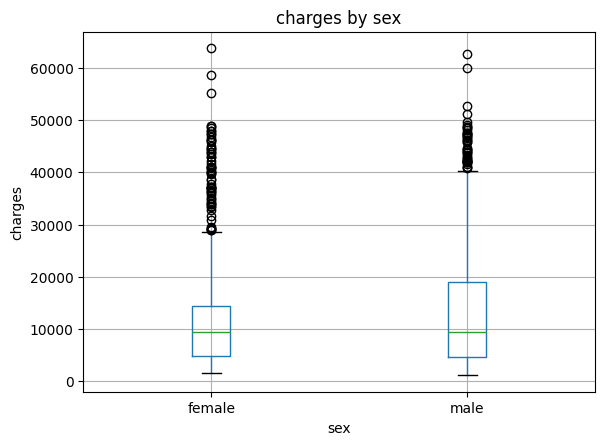

<Figure size 640x480 with 0 Axes>

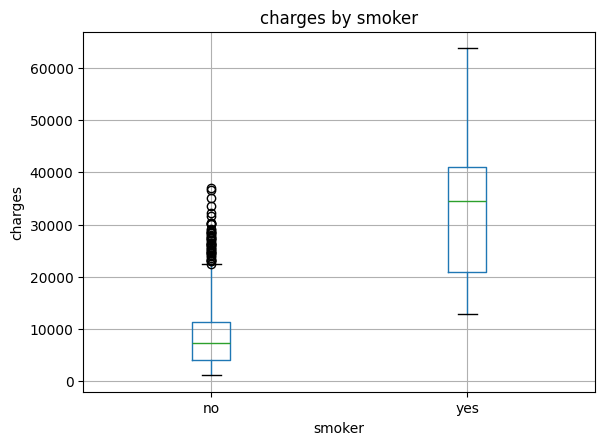

<Figure size 640x480 with 0 Axes>

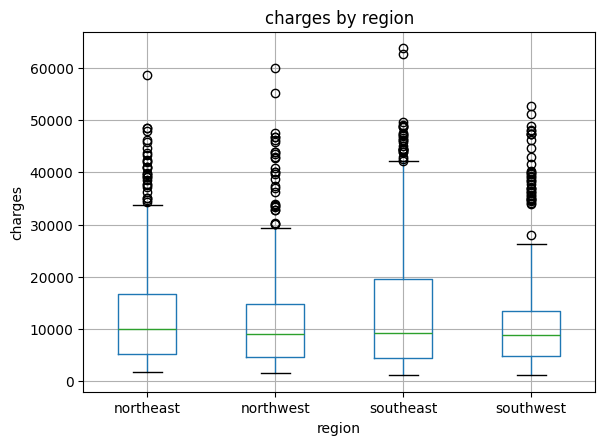

In [16]:
for col in cat_cols:
    plt.figure()
    df.boxplot(column="charges", by=col)
    plt.title(f"charges by {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.show()

## Insights rápidos (Markdown)

- smoker suele disparar charges
- region/sex afectan menos
- outliers fuertes en charges